<a href="https://colab.research.google.com/github/rofusedcryof/timeSeries/blob/main/235314023_TimeSeries.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dionysius Diaz Damar Wilansa
/ 235314023

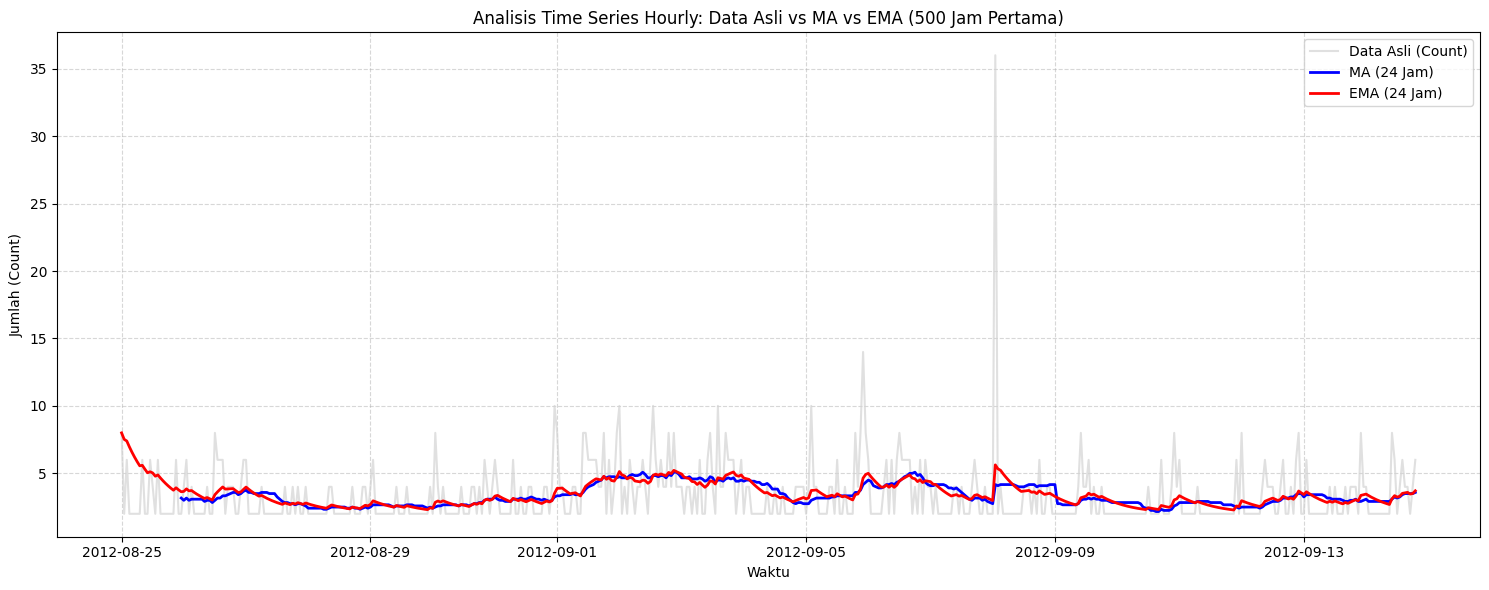

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# 1. Ambil datanya dulu
# Pastiin format tanggalnya bener ya (DD-MM-YYYY HH:MM), biar gak error pas dibaca
df = pd.read_csv('Train.csv')
df['Datetime'] = pd.to_datetime(df['Datetime'], format='mixed', dayfirst=True)
df.set_index('Datetime', inplace=True)

# 2 & 3. Hitung MA & EMA
# Set ke 24 jam, biar sinkron ama data hourly-nya
df['MA_24'] = df['Count'].rolling(window=24).mean()
df['EMA_24'] = df['Count'].ewm(span=24, adjust=False).mean()

# 4. Plot Real Data vs Predicted Data
plt.figure(figsize=(15, 6))

# Plot 500 jam pertama aja biar kelihatan jelas, soalnya kalo semua datanya masuk malah jadi ruwet
subset_df = df.iloc[:500]

plt.plot(subset_df.index, subset_df['Count'], label='Data Asli (Count)', color='lightgray', alpha=0.7)
plt.plot(subset_df.index, subset_df['MA_24'], label='MA (24 Jam)', color='blue', linewidth=2)
plt.plot(subset_df.index, subset_df['EMA_24'], label='EMA (24 Jam)', color='red', linewidth=2)

plt.title('Analisis Time Series Hourly: Data Asli vs MA vs EMA (500 Jam Pertama)')
plt.xlabel('Waktu')
plt.ylabel('Jumlah (Count)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# ***`evaluasi dengan mse atau mae`***

In [ ]:
# Drop baris yang kosong/NaN ya, biar pas ngitung angkanya gak error atau dapet 'inf'
df_eval = df.dropna(subset=['MA_24', 'EMA_24'])

# Cek seberapa meleset hitungan MA-nya (MSE sama MAE)
mse_ma = mean_squared_error(df_eval['Count'], df_eval['MA_24'])
mae_ma = mean_absolute_error(df_eval['Count'], df_eval['MA_24'])

# Cek akurasi si EMA pake MSE dan MAE, mendingan mana nih kira-kira?
mse_ema = mean_squared_error(df_eval['Count'], df_eval['EMA_24'])
mae_ema = mean_absolute_error(df_eval['Count'], df_eval['EMA_24'])

# Menampilkan hasil evaluasi
evaluasi_results = pd.DataFrame({
    'Metrik': ['MSE', 'MAE'],
    'Moving Average (MA)': [mse_ma, mae_ma],
    'Exponential Moving Average (EMA)': [mse_ema, mae_ema]
})

display(evaluasi_results)

,Metrik,Moving Average (MA),Exponential Moving Average (EMA)
0,MSE,5815.468811,4705.856601
1,MAE,46.034419,40.932877


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


Hasil Peramalan Holt-Winters (Lebih Akurat):


/tmp/ipykernel_1499/1498945625.py:19: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_steps, freq='H')


,Forecast_Count
2014-09-26 00:00:00,492.096765
2014-09-26 01:00:00,398.402438
2014-09-26 02:00:00,365.238288
2014-09-26 03:00:00,327.258662
2014-09-26 04:00:00,304.774841


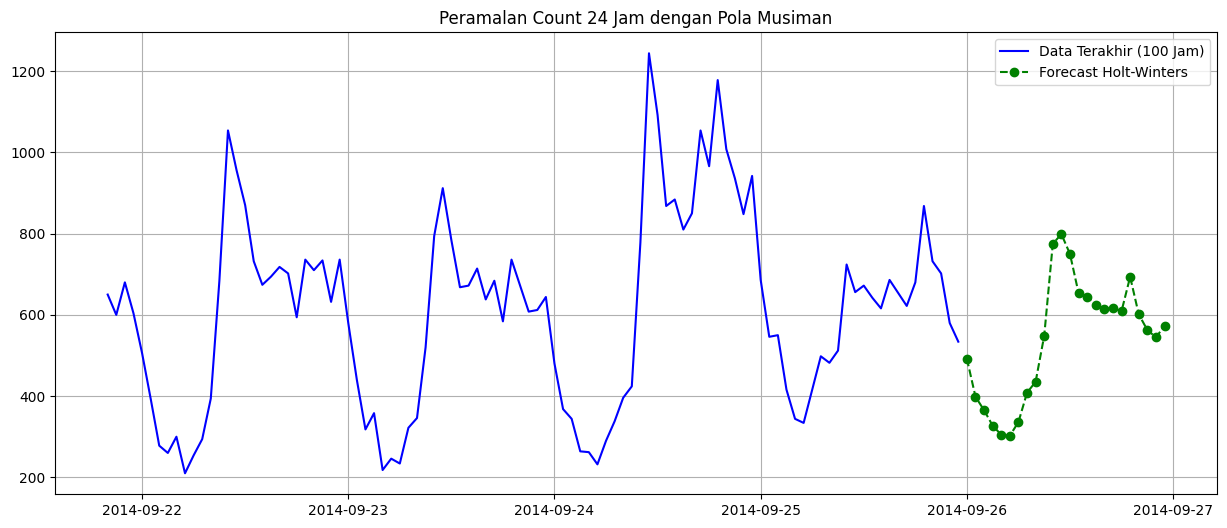

In [ ]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Upgrade modelnya biar bisa baca pola musiman (seasonal)
# Set seasonal_periods=24 karena datamu hourly dan kemungkinan polanya harian
model = ExponentialSmoothing(
    df['Count'],
    trend='add',
    seasonal='add',
    seasonal_periods=24,
    initialization_method='estimated'
).fit()

forecast_steps = 24
forecast = model.forecast(forecast_steps)

# Membuat index waktu untuk forecast
last_date = df.index[-1]
forecast_index = pd.date_range(start=last_date + pd.Timedelta(hours=1), periods=forecast_steps, freq='H')
forecast_df = pd.DataFrame({'Forecast_Count': forecast}, index=forecast_index)

print('Hasil Peramalan Holt-Winters (Lebih Akurat):')
display(forecast_df.head())

# Visualisasi
plt.figure(figsize=(15, 6))
plt.plot(df.index[-100:], df['Count'][-100:], label='Data Terakhir (100 Jam)', color='blue')
plt.plot(forecast_df.index, forecast_df['Forecast_Count'], label='Forecast Holt-Winters', color='green', linestyle='--', marker='o')
plt.title('Peramalan Count 24 Jam dengan Pola Musiman')
plt.legend()
plt.grid(True)
plt.show()